In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kaushaltiwari_tiny_shakespeare_path = kagglehub.dataset_download('kaushaltiwari/tiny-shakespeare')

print('Data source import complete.')


Using Colab cache for faster access to the 'tiny-shakespeare' dataset.
Data source import complete.


In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import kagglehub
import os

### Imported all the required libraries
Now will configure the device to use

In [3]:
#checking which device available
device= lambda x:'cuda'if torch.cuda.is_available() else 'cpu'
device(0)

'cpu'

In [4]:
#Loading the needed data
path = kagglehub.dataset_download("kaushaltiwari/tiny-shakespeare")
print("Path to dataset files:", path)
file=os.listdir(path)
print(file)

Using Colab cache for faster access to the 'tiny-shakespeare' dataset.
Path to dataset files: /kaggle/input/tiny-shakespeare
['tiny-shakespeare.txt']


In [5]:
#Preparing the data step1
exact_file=os.path.join(path,'tiny-shakespeare.txt')
with open(exact_file,'r') as f:
 data=f.read()

# Shakespeare dataset
This dataset is like a story and also kind of drama so I will use the entire data to train
## Now will start building the LSTM

In [6]:
#Preparing the data step2
clean_data=data.lower().split()
unique_words=list(set(clean_data))
no_of_unique_words=len(unique_words)
print(no_of_unique_words,unique_words[:10])

23641 ['moulded', 'throne,', 'ingots', 'thunder-like', 'rome,', 'dens,', 'testy', 'planteth', 'fury:', 'prayers.']


In [7]:
#Preparing the data step3
word_to_idx = {word: idx for idx, word in enumerate(unique_words)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()} # Add this line for easy lookup

# Converting raw text list into a list of integer IDs
numerical_data = [word_to_idx[word] for word in clean_data]

#  Converting that integer list into a PyTorch Tensor
input_tensor = torch.tensor(numerical_data, dtype=torch.long,device=device(0))

# Hidden Size
this is the size of the words which are unique in the traning data that the LSTM needed
to know in order to make it to point to those words

In [8]:
#Embedding the words (converting the words to their specific vectors in vector space)
#I am using the 64 dimention vector to represents the words because it is a tiny model built only using LSTM
#used 250k as the vocabulary len
EMBEDDING_DIM=64
VOCABULARY_LEN=no_of_unique_words
HIDDEN_SIZE=128 #Giving the hidden size tensor size
NO_OF_LAYERS=3 # keeping no of layers of lsmt =3
embedding=nn.Embedding(VOCABULARY_LEN,EMBEDDING_DIM).to(device(0))
embedded_tensor=embedding(input_tensor).to(device(0))
print(embedded_tensor.shape,embedded_tensor.device)

torch.Size([202651, 64]) cpu


In [9]:
#Building the LSTM Model
model=nn.LSTM(
    EMBEDDING_DIM,
    HIDDEN_SIZE,
    NO_OF_LAYERS,
    True,
).to(device(0))
embedded_tensor=embedded_tensor.float()
n=int(0.5*len(embedded_tensor[:]))
fc = nn.Linear(HIDDEN_SIZE, VOCABULARY_LEN).to(device(0))

Epoch: 0, Loss: 10.078116416931152
Epoch: 10, Loss: 9.487631797790527
Epoch: 20, Loss: 7.936655044555664
Epoch: 30, Loss: 7.333163738250732
Epoch: 40, Loss: 7.268700122833252


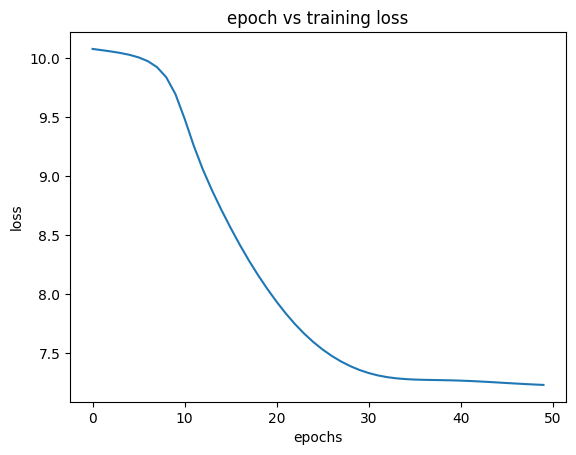

In [10]:
# starting the traning
EPOCHS=50
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(fc.parameters()), # Optimize both LSTM and the linear layer
    lr=0.001
)

# Prepare input and target for training outside the loop, as slices.
# These will be the source for epoch-specific inputs.
source_input_embeddings = embedded_tensor[0:n].float()
source_target_labels = input_tensor[1:n+1]
x=[]
y=[]

for epoch in range(EPOCHS):
    # Creating epoch-specific inputs by cloning and detaching from the source slices.
    # This ensures that each epoch's computation graph is independent and starts from a fresh leaf node.
    train_input_embeddings_epoch = source_input_embeddings.clone().detach()
    train_target_labels_epoch = source_target_labels.clone().detach()

    # Adding a batch dimension to the input embeddings
    # Shape: (sequence_length, 1, embedding_dim) -> batch=sequence_length, seq=1
    lstm_input = train_input_embeddings_epoch.unsqueeze(1).contiguous()

    # Pass through LSTM
    # predict will have shape (sequence_length, batch_size=1, hidden_size)
    predict, _ = model(lstm_input)

    # Remove the batch dimension before passing to the linear layer
    # Shape: (sequence_length, hidden_size)
    predict = predict.squeeze(1)

    # Apply the linear layer to get logits for each word in the vocabulary
    # Shape: (sequence_length, VOCABULARY_LEN)
    output_logits = fc(predict)

    # Calculate loss
    loss = criterion(output_logits, train_target_labels_epoch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    x.append(epoch)
    y.append(loss.item())
    if epoch%10==0:
        print(f"Epoch: {epoch}, Loss: {loss.item()}")
plt.plot(x,y)
plt.title('epoch vs training loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
# Save both model and fc state dicts
torch.save(model.state_dict(), "lstm_model.pth")

In [13]:
# Writing simple sentence for prediction
import torch.nn.functional as F

# Loading the combined state dictionary
checkpoint = torch.load("lstm_model.pth")
# model.load_state_dict(checkpoint['model_state_dict'])
# fc.load_state_dict(checkpoint['fc_state_dict'])

# Setting models to evaluation mode
model.eval()
fc.eval()

# Example input sentence
input_sentence = "your Majesty"
input_words = input_sentence.lower().split()

# Converting words to numerical IDs
# Filtering out words not in word_to_idx to avoid KeyError
known_input_words = [word for word in input_words if word in word_to_idx]
if not known_input_words:
    print("None of the input words are in the vocabulary. Cannot predict.")
else:
    input_ids = [word_to_idx[word] for word in known_input_words]
    input_tensor_pred = torch.tensor(input_ids, dtype=torch.long, device=device(0))
    embedded_input = embedding(input_tensor_pred).float()
    lstm_input_pred = embedded_input.contiguous()
    predict_output, _ = model(lstm_input_pred)
    last_lstm_output = predict_output[-1]
    output_logits = fc(last_lstm_output)
    probabilities = F.softmax(output_logits, dim=-1)
    predicted_word_idx = torch.argmax(probabilities).item()

    # Getting the actual word
    predicted_word = idx_to_word[predicted_word_idx]

    print(f"Input sentence: '{input_sentence}'")
    print(f"Predicted next word: '{predicted_word}'")


Input sentence: 'your Majesty'
Predicted next word: 'and'


In [12]:
# Function to generate a sequence of words
def generate_text(start_sequence, num_words_to_generate, model, fc, embedding, word_to_idx, idx_to_word, device):
    model.eval()
    fc.eval()

    # Converting start sequence to IDs, handling unknown words
    input_ids = [word_to_idx[word.lower()] for word in start_sequence.lower().split() if word.lower() in word_to_idx]
    if not input_ids:
        return "Error: Starting sequence contains no known words.", [], 0.0 # Return empty list and 0.0 for probabilities/average

    generated_sequence_ids = list(input_ids)
    predicted_word_probabilities = [] # Store probabilities of predicted words

    for _ in range(num_words_to_generate):
        # Preparing the current sequence for prediction
        current_input_tensor = torch.tensor(generated_sequence_ids, dtype=torch.long, device=device(0))
        embedded_input = embedding(current_input_tensor).float()
        lstm_input_pred = embedded_input.unsqueeze(1).contiguous()

        # Passing through LSTM
        predict_output, _ = model(lstm_input_pred)

        # Geting the output corresponding to the last word of the input sequence
        last_lstm_output = predict_output[-1].squeeze(0)

        # Applying the fully connected layer to get logits
        output_logits = fc(last_lstm_output)

        # Applying softmax to get probabilities and predict the next word
        probabilities = F.softmax(output_logits, dim=-1)
        predicted_word_idx = torch.argmax(probabilities).item()

        # Get the probability of the predicted word
        predicted_prob = probabilities[predicted_word_idx].item()
        predicted_word_probabilities.append(predicted_prob)

        # Adding the predicted word to the sequence
        generated_sequence_ids.append(predicted_word_idx)

    # Calculate average confidence of the predicted words
    average_confidence = sum(predicted_word_probabilities) / len(predicted_word_probabilities) if predicted_word_probabilities else 0.0

    # Converting the entire generated sequence of IDs back to words
    generated_text_str = ' '.join([idx_to_word[idx] for idx in generated_sequence_ids])
    return generated_text_str, predicted_word_probabilities, average_confidence


# Example of text generation
start_sequence = "the king said"
num_words = 20  # Number of words to generate after the start sequence

generated_text, probabilities_list, avg_confidence = generate_text(
    start_sequence,
    num_words,
    model,
    fc,
    embedding,
    word_to_idx,
    idx_to_word,
    device
)

print(f"Generated text based on '{start_sequence}':\n{generated_text}")
print(f"Probabilities of predicted words: {[f'{p*100:.2f}%' for p in probabilities_list]}")
print(f"Average confidence of predicted words: {avg_confidence*100:.2f}%")

Generated text based on 'the king said':
the king said the the the the the the the the the the the the the the the the the the the the
Probabilities of predicted words: ['2.98%', '4.35%', '4.57%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%', '4.61%']
Average confidence of predicted words: 4.52%
